# Cold-Start Performance Analysis

This notebook analyses the cold-start performance of Node.js, Bun and Deno.

Cold-start time represents the elapsed time from runtime process creation until the benchmark program emits the expected `READY` signal. Lower cold-start time indicates better performance.

The analysis includes:

1. Dataset import and verification
2. Descriptive statistics
3. Visualisation
4. Assumption diagnostics
5. Repeated-measures omnibus testing
6. Pairwise post-hoc comparisons
7. Holm correction for multiple comparisons
8. Effect-size estimation and 95% confidence intervals

In [1]:
library(tidyverse)
library(rstatix)
library(effectsize)

project_root <- normalizePath(
  "..",
  winslash = "/"
)

project_root

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rstatix' was built under R version 4.6.1"

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter


Warning message:
"package 'effectsize' was built under R version 4.6.1"

Attaching package: 'effectsize'


The following objects are masked from 'package:rstatix':

    cohens_d, eta_squared, omega_squared




[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study"

In [2]:
cold_start_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "cold_start",
    "cold_start_final.csv"
  ),
  show_col_types = FALSE
)

glimpse(cold_start_final)

Rows: 90
Columns: 16
$ run_id          <chr> "cold_start_s01_r01_bun", "cold_start_s01_r01_node", "…
$ session_id      <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ sequence        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ repetition      <dbl> 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, …
$ runtime         <chr> "bun", "node", "deno", "node", "deno", "bun", "deno", …
$ shuffle_seed    <dbl> 20260805, 20260805, 20260805, 20260806, 20260806, 2026…
$ started_at      <dttm> 2026-08-04 17:46:51, 2026-08-04 17:46:52, 2026-08-04 …
$ finished_at     <dttm> 2026-08-04 17:46:51, 2026-08-04 17:46:53, 2026-08-04 …
$ status          <chr> "success", "success", "success", "success", "success",…
$ startup_time_ns <dbl> 178285500, 164015500, 138049000, 148614900, 119818900,…
$ startup_time_ms <dbl> 178.2855, 164.0155, 138.0490, 148.6149, 119.8189, 184.…
$ observed_output <chr> "READY", "READY", "READY", "READY", "READY", "READY", …
$ program_file    <

In [3]:
dim(cold_start_final)

[1] 90 16

In [4]:
table(
  cold_start_final$runtime,
  useNA = "ifany"
)


 bun deno node 
  30   30   30 

In [5]:
names(cold_start_final)

[1] "run_id"          "session_id"      "sequence"        "repetition"     
 [5] "runtime"         "shuffle_seed"    "started_at"      "finished_at"    
 [9] "status"          "startup_time_ns" "startup_time_ms" "observed_output"
[13] "program_file"    "stdout_log"      "stderr_log"      "error_message"

### Dataset Verification

The processed cold-start dataset contained 90 observations and 16 variables. Each runtime contributed 30 observations, providing a balanced repeated-measures dataset.

The primary dependent variable for analysis was `startup_time_ms`. Runtime order was randomised during data collection, while the `repetition` variable identifies the matched measurement blocks used for repeated-measures statistical analysis.

Only light verification is performed here because the complete dataset quality audit was conducted during the benchmark implementation and processing stage.

In [6]:
cold_start_final <- cold_start_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c("node", "bun", "deno"),
      labels = c("Node.js", "Bun", "Deno")
    )
  )

table(cold_start_final$runtime)


Node.js     Bun    Deno 
     30      30      30 

In [7]:
cold_start_checks <- tibble(
  total_observations = nrow(cold_start_final),
  missing_startup_times =
    sum(is.na(cold_start_final$startup_time_ms)),
  non_positive_startup_times =
    sum(cold_start_final$startup_time_ms <= 0),
  unique_repetitions =
    n_distinct(cold_start_final$repetition),
  successful_observations =
    sum(cold_start_final$status == "success")
)

cold_start_checks

total_observations,missing_startup_times,non_positive_startup_times,unique_repetitions,successful_observations
<int>,<int>,<int>,<int>,<int>
90,0,0,30,90


In [8]:
cold_start_final |>
  count(repetition) |>
  count(n)

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


n,nn
<int>,<int>
3,30


In [9]:
# Descriptive statistics
cold_start_summary <- cold_start_final |>
  group_by(runtime) |>
  summarise(
    n = n(),
    mean_ms = mean(startup_time_ms),
    median_ms = median(startup_time_ms),
    sd_ms = sd(startup_time_ms),
    se_ms = sd_ms / sqrt(n),

    ci_margin =
      qt(0.975, df = n - 1) * se_ms,

    ci_lower =
      mean_ms - ci_margin,

    ci_upper =
      mean_ms + ci_margin,

    iqr_ms = IQR(startup_time_ms),
    min_ms = min(startup_time_ms),
    max_ms = max(startup_time_ms),

    .groups = "drop"
  )

cold_start_summary

runtime,n,mean_ms,median_ms,sd_ms,se_ms,ci_margin,ci_lower,ci_upper,iqr_ms,min_ms,max_ms
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Node.js,30,160.7457,154.3487,17.72058,3.235320,6.616972,154.1288,167.3627,15.461325,141.4879,208.3294
Bun,30,196.0424,187.7892,25.82093,4.714235,9.641693,186.4007,205.6841,16.190700,169.1882,283.0018
Deno,30,140.2175,132.0528,36.07831,6.586969,13.471864,126.7456,153.6894,8.323725,115.7602,281.6167


### Cold-Start Descriptive Results

All 90 planned cold-start observations were available for analysis, with 30 successful measurements per runtime and complete three-runtime blocks across all repetitions.

Deno recorded the lowest mean cold-start time (140.22 ms), followed by Node.js (160.75 ms) and Bun (196.04 ms). The corresponding medians were 132.05 ms, 154.35 ms and 187.79 ms, respectively.

Deno showed the greatest variability in startup time, with a standard deviation of 36.08 ms and a maximum observed time of 281.62 ms. Bun also contained comparatively slow observations, reaching a maximum of 283.00 ms. These distributional characteristics were examined further using paired-difference diagnostics before inferential testing.

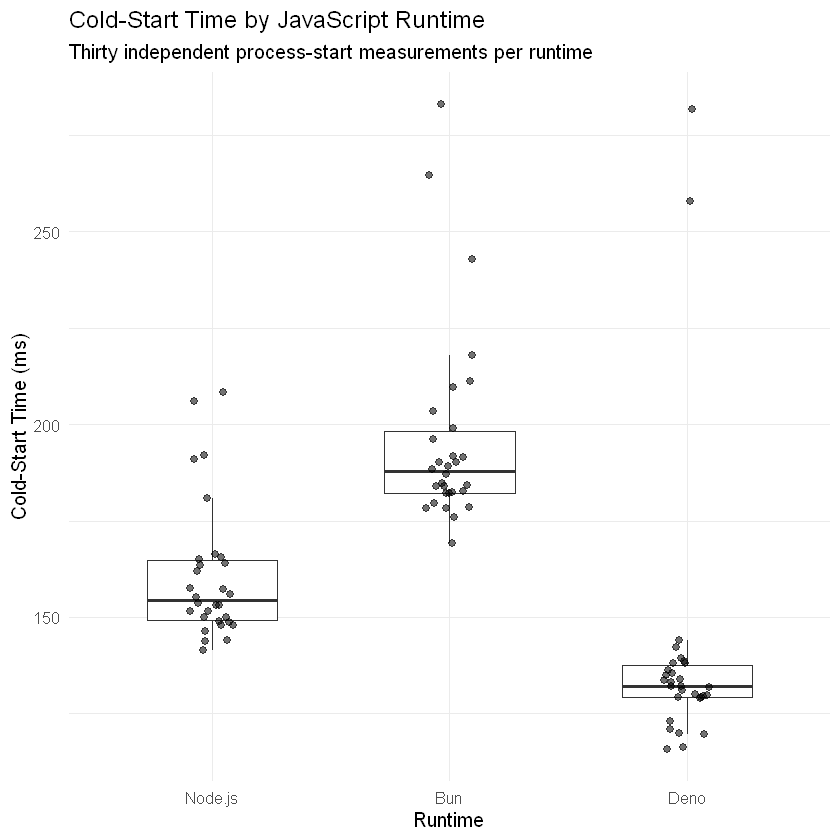

In [10]:
cold_start_plot <- ggplot(
  cold_start_final,
  aes(
    x = runtime,
    y = startup_time_ms
  )
) +
  geom_boxplot(
    width = 0.55,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.10,
    alpha = 0.55,
    size = 1.8
  ) +
  labs(
    title = "Cold-Start Time by JavaScript Runtime",
    subtitle = "Thirty independent process-start measurements per runtime",
    x = "Runtime",
    y = "Cold-Start Time (ms)"
  ) +
  theme_minimal(base_size = 12)

cold_start_plot

In [11]:
cold_start_wide <- cold_start_final |>
  select(
    repetition,
    runtime,
    startup_time_ms
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = startup_time_ms
  )

cold_start_wide

repetition,Bun,Node.js,Deno
<dbl>,<dbl>,<dbl>,<dbl>
1,178.2855,164.0155,138.0490
2,184.0679,148.6149,119.8189
3,283.0018,190.9830,136.1296
4,217.9459,165.0049,142.2027
5,188.4675,147.8253,133.1165
6,184.2291,163.3829,134.9000
7,184.6302,166.4429,138.5500
8,187.1108,192.0619,133.5545
9,191.6748,151.6288,130.1001


In [12]:
dim(cold_start_wide)
colSums(is.na(cold_start_wide))

[1] 30  4

repetition        Bun    Node.js       Deno 
         0          0          0          0

In [13]:
cold_start_differences <- cold_start_wide |>
  mutate(
    `Node.js - Bun` =
      `Node.js` - Bun,

    `Node.js - Deno` =
      `Node.js` - Deno,

    `Bun - Deno` =
      Bun - Deno
  ) |>
  select(
    repetition,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

In [14]:
cold_start_shapiro <- cold_start_differences |>
  group_by(comparison) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),
    p_value =
      shapiro.test(difference)$p.value,
    .groups = "drop"
  )

cold_start_shapiro

comparison,W,p_value
<chr>,<dbl>,<dbl>
Bun - Deno,0.7356303,5.380160e-06
Node.js - Bun,0.8901191,4.855557e-03
Node.js - Deno,0.6535820,3.521021e-07


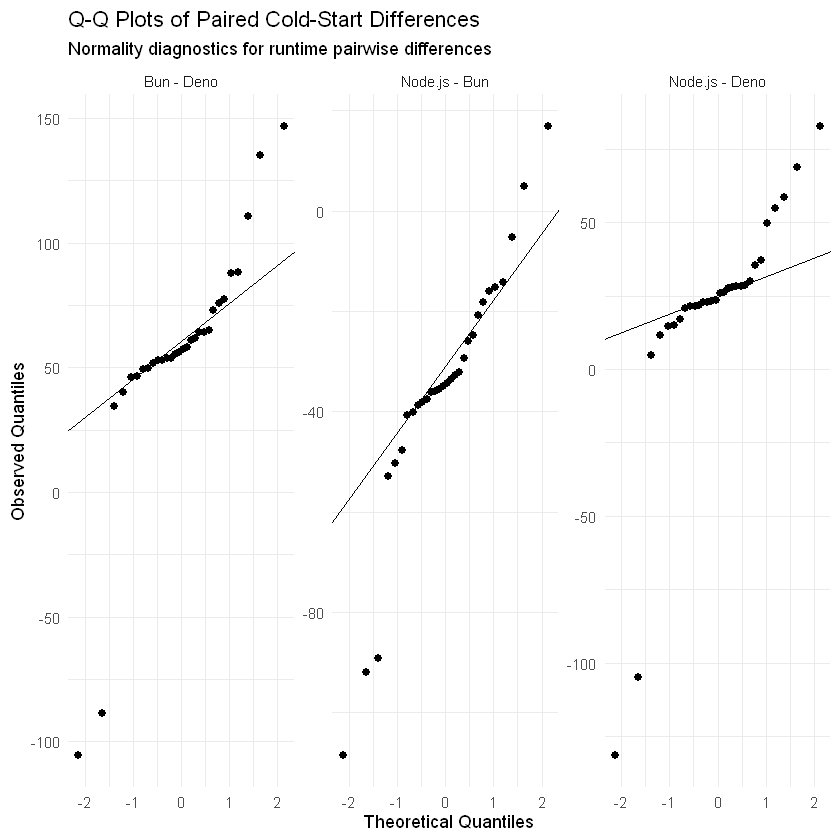

In [15]:
cold_start_qq <- ggplot(
  cold_start_differences,
  aes(sample = difference)
) +
  stat_qq(size = 1.8) +
  stat_qq_line() +
  facet_wrap(
    ~ comparison,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired Cold-Start Differences",
    subtitle = "Normality diagnostics for runtime pairwise differences",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(base_size = 11)

cold_start_qq

### Cold-Start Assumption Assessment

Normality of the paired runtime differences was assessed using Shapiro–Wilk tests and Q–Q plots.

All three paired comparisons showed statistically significant departures from normality: Bun–Deno (p < .001), Node.js–Bun (p = .005), and Node.js–Deno (p < .001). The Q–Q plots also showed substantial departures from the reference lines, particularly in the distribution tails.

Several comparatively slow but technically valid cold-start observations were present. These observations were retained because they passed the benchmark validation criteria.

Because the normality assumption required for repeated-measures ANOVA was not satisfied, cold-start time was analysed using the non-parametric Friedman test.

In [16]:
cold_start_friedman_test <- stats::friedman.test(
  startup_time_ms ~ runtime | repetition,
  data = cold_start_final
)

cold_start_friedman_test


	Friedman rank sum test

data:  startup_time_ms and runtime and repetition
Friedman chi-squared = 45.067, df = 2, p-value = 1.636e-10


In [17]:
cold_start_kendalls_w <-
  unname(cold_start_friedman_test$statistic) /
  (
    n_distinct(cold_start_final$repetition) *
    (n_distinct(cold_start_final$runtime) - 1)
  )

cold_start_friedman_results <- tibble(
  chi_square =
    unname(cold_start_friedman_test$statistic),

  df =
    unname(cold_start_friedman_test$parameter),

  p_value =
    cold_start_friedman_test$p.value,

  kendalls_w =
    cold_start_kendalls_w
)

cold_start_friedman_results

chi_square,df,p_value,kendalls_w
<dbl>,<dbl>,<dbl>,<dbl>
45.06667,2,1.636431e-10,0.7511111


### Friedman Test Results for Cold-Start Time

The Friedman test identified a statistically significant difference in cold-start time between Node.js, Bun and Deno, χ²(2) = 45.07, p < .001.

Kendall's W was .751, indicating a strong and consistent runtime effect across the 30 matched repetitions.

Because the omnibus Friedman test was statistically significant, paired post-hoc comparisons were conducted to determine which runtime pairs differed.

In [18]:
cold_start_exact_check <- cold_start_differences |>
  group_by(comparison) |>
  summarise(
    zero_differences =
      sum(difference == 0),

    duplicated_absolute_differences =
      sum(
        duplicated(abs(difference))
      ),

    .groups = "drop"
  )

cold_start_exact_check

comparison,zero_differences,duplicated_absolute_differences
<chr>,<int>,<int>
Bun - Deno,0,0
Node.js - Bun,0,0
Node.js - Deno,0,0


In [19]:
cold_start_posthoc <- bind_rows(

  tibble(
    group1 = "Node.js",
    group2 = "Bun",
    difference =
      cold_start_wide$`Node.js` -
      cold_start_wide$Bun
  ),

  tibble(
    group1 = "Node.js",
    group2 = "Deno",
    difference =
      cold_start_wide$`Node.js` -
      cold_start_wide$Deno
  ),

  tibble(
    group1 = "Bun",
    group2 = "Deno",
    difference =
      cold_start_wide$Bun -
      cold_start_wide$Deno
  )
) |>
  group_by(
    group1,
    group2
  ) |>
  summarise(
    statistic =
      unname(
        stats::wilcox.test(
          difference,
          mu = 0,
          exact = TRUE
        )$statistic
      ),

    p_raw =
      stats::wilcox.test(
        difference,
        mu = 0,
        exact = TRUE
      )$p.value,

    median_difference =
      median(difference),

    .groups = "drop"
  ) |>
  mutate(
    p_holm =
      p.adjust(
        p_raw,
        method = "holm"
      ),

    significant =
      ifelse(
        p_holm < 0.05,
        "Yes",
        "No"
      )
  )

cold_start_posthoc

group1,group2,statistic,p_raw,median_difference,p_holm,significant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Bun,Deno,412,7.910654e-05,56.64810,1.582131e-04,Yes
Node.js,Bun,7,3.539026e-08,-34.64220,1.061708e-07,Yes
Node.js,Deno,406,1.528710e-04,24.68765,1.582131e-04,Yes


### Cold-Start Post-Hoc Results

Pairwise Wilcoxon signed-rank tests were performed following the statistically significant Friedman test. Exact inference was used because no zero paired differences or tied absolute differences were present. Holm's correction was applied across the three runtime comparisons.

All three pairwise comparisons remained statistically significant after adjustment.

- **Node.js vs Bun:** median paired difference = -34.64 ms, Holm-adjusted p < .001, indicating lower cold-start time for Node.js.
- **Node.js vs Deno:** median paired difference = 24.69 ms, Holm-adjusted p < .001, indicating lower cold-start time for Deno.
- **Bun vs Deno:** median paired difference = 56.65 ms, Holm-adjusted p < .001, indicating lower cold-start time for Deno.

The pairwise results therefore support the descriptive ordering of Deno as the fastest-starting runtime, followed by Node.js and then Bun.

In [20]:
cold_start_effects <- bind_rows(

  tibble(
    group1 = "Node.js",
    group2 = "Bun",
    difference =
      cold_start_wide$`Node.js` -
      cold_start_wide$Bun
  ),

  tibble(
    group1 = "Node.js",
    group2 = "Deno",
    difference =
      cold_start_wide$`Node.js` -
      cold_start_wide$Deno
  ),

  tibble(
    group1 = "Bun",
    group2 = "Deno",
    difference =
      cold_start_wide$Bun -
      cold_start_wide$Deno
  )
) |>
  group_by(
    group1,
    group2
  ) |>
  group_modify(
    ~ {

      differences <- .x$difference

      ranks <- rank(
        abs(differences),
        ties.method = "average"
      )

      w_positive <-
        sum(ranks[differences > 0])

      w_negative <-
        sum(ranks[differences < 0])

      rank_biserial <-
        (w_positive - w_negative) /
        (w_positive + w_negative)

      wilcox_result <- stats::wilcox.test(
        differences,
        mu = 0,
        exact = TRUE,
        conf.int = TRUE,
        conf.level = 0.95
      )

      tibble(
        median_difference =
          median(differences),

        hodges_lehmann =
          unname(wilcox_result$estimate),

        difference_ci_lower =
          wilcox_result$conf.int[1],

        difference_ci_upper =
          wilcox_result$conf.int[2],

        effect_type =
          "Rank-biserial correlation",

        effect_size =
          rank_biserial
      )
    }
  )

cold_start_effects

group1,group2,median_difference,hodges_lehmann,difference_ci_lower,difference_ci_upper,effect_type,effect_size
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Bun,Deno,56.64810,58.62035,52.4117,68.57525,Rank-biserial correlation,0.7720430
Node.js,Bun,-34.64220,-33.76665,-39.4002,-26.28895,Rank-biserial correlation,-0.9698925
Node.js,Deno,24.68765,25.20060,21.1441,31.91700,Rank-biserial correlation,0.7462366


### Cold-Start Effect Sizes

Matched-pairs rank-biserial correlations and Hodges–Lehmann location-shift estimates with 95% confidence intervals were calculated for the three runtime comparisons.

All comparisons showed substantial runtime effects. Deno had lower cold-start time than Bun, with a Hodges–Lehmann difference of 58.62 ms (95% CI [52.41, 68.58]) and a rank-biserial correlation of .772.

Node.js had lower cold-start time than Bun, with a Hodges–Lehmann difference of -33.77 ms (95% CI [-39.40, -26.29]) and a rank-biserial correlation of -.970.

Deno also had lower cold-start time than Node.js. The Node.js-Deno comparison produced a Hodges–Lehmann difference of 25.20 ms (95% CI [21.14, 31.92]) and a rank-biserial correlation of .746.

Taken together with the descriptive and post-hoc results, the cold-start analysis therefore produced the ordering **Deno → Node.js → Bun**, from lowest to highest startup time.

In [21]:
cold_start_final_results <- cold_start_posthoc |>
  left_join(
    cold_start_effects |>
      ungroup() |>
      select(
        group1,
        group2,
        hodges_lehmann,
        difference_ci_lower,
        difference_ci_upper,
        effect_type,
        effect_size
      ),
    by = c(
      "group1",
      "group2"
    )
  ) |>
  select(
    group1,
    group2,
    median_difference,
    hodges_lehmann,
    difference_ci_lower,
    difference_ci_upper,
    p_holm,
    significant,
    effect_type,
    effect_size
  )

cold_start_final_results

group1,group2,median_difference,hodges_lehmann,difference_ci_lower,difference_ci_upper,p_holm,significant,effect_type,effect_size
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
Bun,Deno,56.64810,58.62035,52.4117,68.57525,1.582131e-04,Yes,Rank-biserial correlation,0.7720430
Node.js,Bun,-34.64220,-33.76665,-39.4002,-26.28895,1.061708e-07,Yes,Rank-biserial correlation,-0.9698925
Node.js,Deno,24.68765,25.20060,21.1441,31.91700,1.582131e-04,Yes,Rank-biserial correlation,0.7462366


In [22]:
#save it
cold_start_results_directory <- file.path(
  project_root,
  "results",
  "tables",
  "cold_start"
)

dir.create(
  cold_start_results_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

write_csv(
  cold_start_summary,
  file.path(
    cold_start_results_directory,
    "cold_start_descriptive_summary.csv"
  )
)

write_csv(
  cold_start_final_results,
  file.path(
    cold_start_results_directory,
    "cold_start_inferential_results.csv"
  )
)